TF-IDF and logistic regression on the 3-way labelled data as a quick starting baseline before moving onto BERT

In [ ]:
import pandas as pd
import os
import seaborn as sns
import json 

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline 
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
os.makedirs('../results', exist_ok=True)

In [3]:
data_dir = os.path.join('..', 'data', 'processed', 'US')

train_path = os.path.join(data_dir, 'multimodal_train.tsv')
val_path = os.path.join(data_dir, 'multimodal_validate.tsv')

train_df = pd.read_csv(train_path, sep='\t')
val_df = pd.read_csv(val_path, sep='\t')

### 1. With class_weight = balanced

In [4]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=3)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000))
])

X = train_df['clean_title']
y = train_df['3_way_label']
pipe.fit(X, y)

X_val = val_df['clean_title']
y_val = val_df['3_way_label']
y_pred = pipe.predict(X_val)
print(classification_report(y_val, y_pred)
)

              precision    recall  f1-score   support

           0       0.73      0.79      0.76     23320
           1       0.31      0.88      0.46      1365
           2       0.86      0.75      0.81     34657

    accuracy                           0.77     59342
   macro avg       0.64      0.81      0.68     59342
weighted avg       0.80      0.77      0.78     59342



<Axes: >

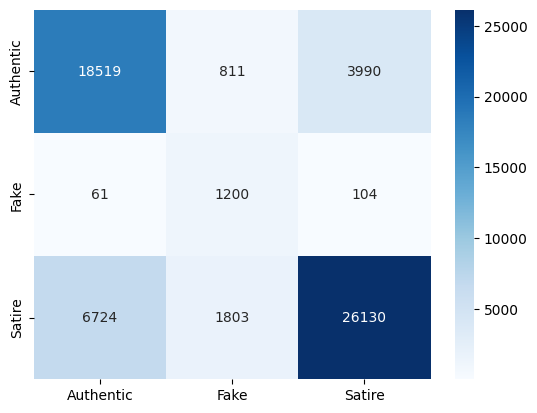

In [5]:
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Authentic','Fake','Satire'],
               yticklabels=['Authentic','Fake','Satire'], cmap='Blues'
            )

- **Accuracy  0.77, weighted F1 0.78**. Meaningfully above random classification
- **Macro F1 0.68**
- Extremely imbalanced dataset - fake has very few samples (<3% of dataset). Good recall but v poor precision - model over-predicts fake. Better than converse for fake news detection, where false positives are less impactful than false negatives. But class imbalance is something to bear in mind. 
- Address class imbalance by using weighted loss in training but doesn't fully solve issue. 



In [7]:
balanced_results = {
    'model': 'tfidf_logreg_balanced',
    'split': 'validation',
    'accuracy': 0.77,
    'macro_f1': 0.68,
    'weighted_f1': 0.78,
    'per_class': {
        'authentic': {'precision': 0.73, 'recall': 0.79, 'f1': 0.76, 'support': 23320},
        'fake':      {'precision': 0.31, 'recall': 0.88, 'f1': 0.46, 'support': 1365},
        'satire':    {'precision': 0.86, 'recall': 0.75, 'f1': 0.81, 'support': 34657},
    },
}
with open('../results/baseline_metrics.json', 'w') as f:
    json.dump(balanced_results, f, indent=2)

### 2. Try class weight = None

In [8]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=3)),
    ('lr', LogisticRegression(class_weight=None, max_iter=1000))
])

X = train_df['clean_title']
y = train_df['3_way_label']
pipe.fit(X, y)

X_val = val_df['clean_title']
y_val = val_df['3_way_label']
y_pred = pipe.predict(X_val)
print(classification_report(y_val, y_pred)
)

              precision    recall  f1-score   support

           0       0.77      0.75      0.76     23320
           1       0.86      0.59      0.70      1365
           2       0.83      0.85      0.84     34657

    accuracy                           0.81     59342
   macro avg       0.82      0.73      0.77     59342
weighted avg       0.80      0.81      0.80     59342



<Axes: >

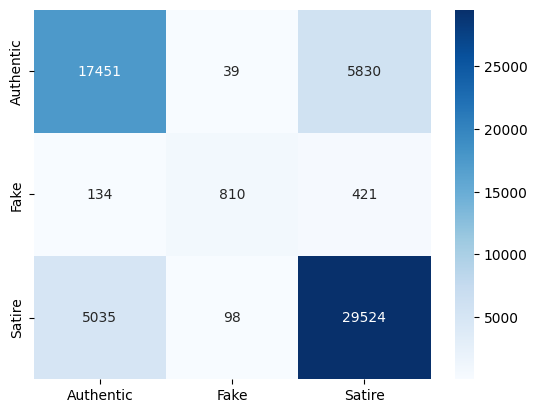

In [9]:
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Authentic','Fake','Satire'],
               yticklabels=['Authentic','Fake','Satire'], cmap='Blues'
            )

Unweighted version is a notably better baseline - better on every metric other than Fake recall. 

 There must be a small set of strong lexical cues for Fake content (clickbait phrases, propaganda-poster language). When the loss function weights all 3 classes equally, the model spreads its capacity to capture the cues across many less-confident predictions - detrimental. Without weighting, it learns the high-confidence patterns and uses them sparingly — high precision (0.86), modest recall (0.59), strong F1.

In [10]:
none_results = {
    'model': 'tfidf_logreg',
    'split': 'validation',
    'class_weight': None,
    'accuracy': 0.81,
    'macro_f1': 0.77,
    'weighted_f1': 0.80,
    'per_class': {
        'authentic': {'precision': 0.77, 'recall': 0.75, 'f1': 0.76, 'support': 23320},
        'fake':      {'precision': 0.86, 'recall': 0.59, 'f1': 0.70, 'support': 1365},
        'satire':    {'precision': 0.83, 'recall': 0.85, 'f1': 0.84, 'support': 34657},
    },
}

with open('../results/baseline_metrics.json', 'w') as f:
    json.dump(none_results, f, indent=2)